In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:

# Getting the dataset

df = pd.read_csv("/content/CC GENERAL.csv")


In [3]:

# Understanding the dataset

print(df.head())
print(df.info())
print(df.describe())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

In [4]:

# Data Preprocessing
# Customer Id not useful
df.drop(columns=['CUST_ID'], inplace=True)
# Check for NULL values
print("Null values:\n", df.isnull().sum())

# Drop NULL values if any
df.dropna(inplace=True)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


Null values:
 BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


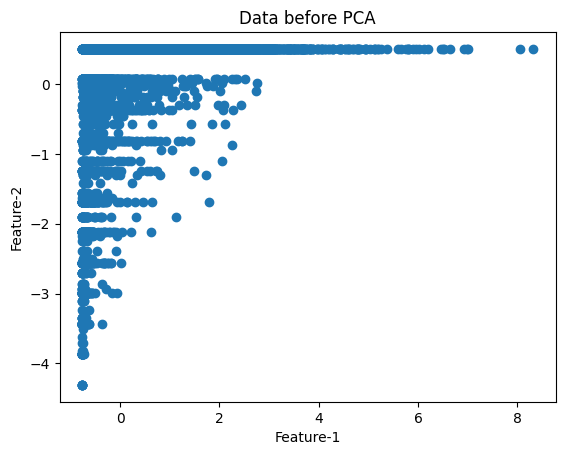

In [5]:
plt.scatter(X_scaled[:,0], X_scaled[:,1])
plt.xlabel("Feature-1")
plt.ylabel("Feature-2")
plt.title("Data before PCA")
plt.show()


In [6]:

# Developing K-Means Model

# Finding best K using Elbow Method & Silhouette Score
wcss = []
sil_scores = []
K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))


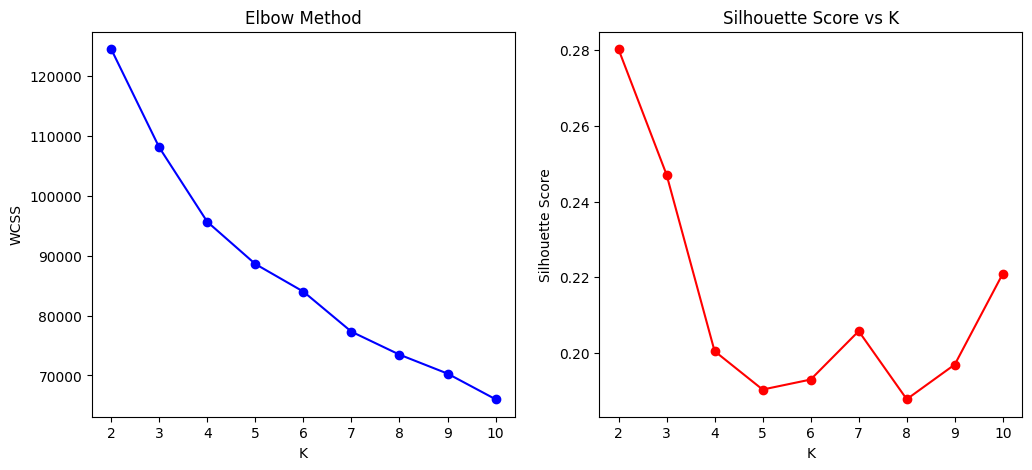

In [7]:
# Plotting K vs WCSS & K vs Silhouette
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, wcss, 'bo-')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K, sil_scores, 'ro-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.show()

In [8]:
best_k_silhouette = K[np.argmax(sil_scores)]
print("Best K (Silhouette):", best_k_silhouette)

Best K (Silhouette): 2


In [9]:
!pip install kneed


In [10]:
from kneed import KneeLocator



knee = KneeLocator(
    K,
    wcss,
    curve='convex',
    direction='decreasing'
)

best_k_elbow = knee.elbow
print("Best K (Elbow):", best_k_elbow)


Best K (Elbow): 4


In [11]:
# Fit K-Means with best K
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

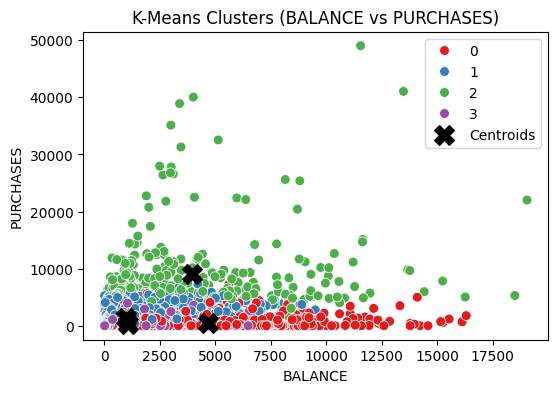

In [12]:

# Visualize Clusters using two original features


plt.figure(figsize=(6, 4))

sns.scatterplot(
    x='BALANCE',
    y='PURCHASES',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=50
)

# Plot centroids (inverse scaling)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, df.columns.get_loc('BALANCE')],
    centroids[:, df.columns.get_loc('PURCHASES')],
    s=200,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clusters (BALANCE vs PURCHASES)')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.legend()
plt.show()


In [13]:
# Predicting new data point cluster
new_customer = pd.DataFrame({
    'BALANCE': [500],
    'BALANCE_FREQUENCY': [1.0],
    'PURCHASES': [200],
    'ONEOFF_PURCHASES': [150],
    'INSTALLMENTS_PURCHASES': [50],
    'CASH_ADVANCE': [0],
    'PURCHASES_FREQUENCY': [0.6],
    'ONEOFF_PURCHASES_FREQUENCY': [0.4],
    'PURCHASES_INSTALLMENTS_FREQUENCY': [0.3],
    'CASH_ADVANCE_FREQUENCY': [0],
    'CASH_ADVANCE_TRX': [0],
    'PURCHASES_TRX': [10],
    'CREDIT_LIMIT': [3000],
    'PAYMENTS': [400],
    'MINIMUM_PAYMENTS': [200],
    'PRC_FULL_PAYMENT': [0.5],
    'TENURE': [12]
})

new_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans.predict(new_scaled)
print("Predicted Cluster:", predicted_cluster)


Predicted Cluster: [1]


In [14]:

# Evaluation Metrics

print("Silhouette Score:", silhouette_score(X_scaled, clusters))
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, clusters))
print("WCSS (Inertia):", kmeans.inertia_)

Silhouette Score: 0.2004866872384794
Davies-Bouldin Index: 1.557067601658335
WCSS (Inertia): 95661.10686235351
